In [31]:
!pip -q install streamlit

import re
import string
import json
import pickle
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import EarlyStopping


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

print(
    "GPU:",
    tf.config.list_physical_devices("GPU")
)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [32]:
from google.colab import files

print(
    "Upload Dataset---Hate-Speech-Detection-using-Deep-Learning.csv"
)

uploaded = files.upload()

CSV_PATH = next(
    iter(uploaded)
)

print("Uploaded:", CSV_PATH)

Upload Dataset---Hate-Speech-Detection-using-Deep-Learning.csv


Saving Dataset---Hate-Speech-Detection-using-Deep-Learning.csv to Dataset---Hate-Speech-Detection-using-Deep-Learning (1).csv
Uploaded: Dataset---Hate-Speech-Detection-using-Deep-Learning (1).csv


In [33]:
df = pd.read_csv(
    CSV_PATH
)

print(
    "Dataset shape:",
    df.shape
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)

print(
    "\nMissing values:"
)

print(
    df.isnull().sum()
)

print(
    "\nDuplicate rows:",
    df.duplicated().sum()
)

df.head()

Dataset shape: (24783, 2)

Columns:
['class', 'tweet']

Missing values:
class    0
tweet    0
dtype: int64

Duplicate rows: 0


,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [34]:
CLASS_NAMES = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neither"
}

df["label_name"] = df[
    "class"
].map(
    CLASS_NAMES
)

df.head()

,class,tweet,label_name
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neither
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language


In [35]:
class_counts = (
    df["class"]
    .value_counts()
    .sort_index()
)

class_percentages = (
    df["class"]
    .value_counts(
        normalize=True
    )
    .sort_index()
    * 100
).round(2)

distribution = pd.DataFrame(
    {
        "Class": class_counts.index,

        "Label": [
            CLASS_NAMES[i]
            for i
            in class_counts.index
        ],

        "Count":
            class_counts.values,

        "Percentage":
            class_percentages.values
    }
)

distribution

,Class,Label,Count,Percentage
0,0,Hate Speech,1430,5.77
1,1,Offensive Language,19190,77.43
2,2,Neither,4163,16.80


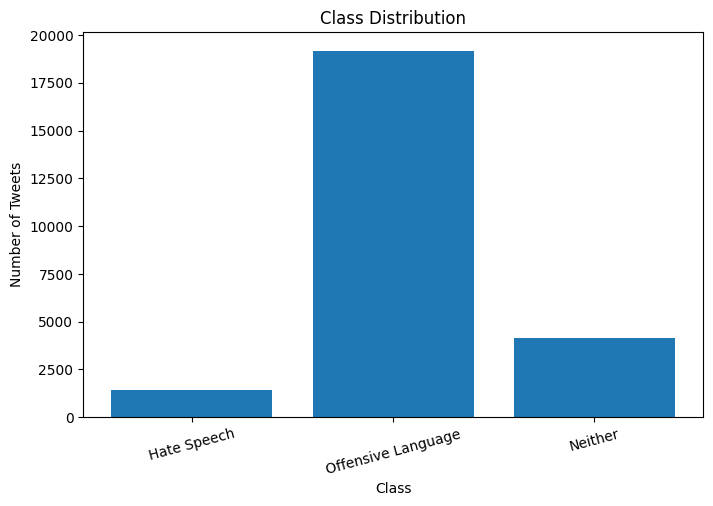

In [36]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    distribution["Label"],
    distribution["Count"]
)

plt.title(
    "Class Distribution"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Tweets"
)

plt.xticks(
    rotation=15
)

plt.show()

In [37]:
stemmer = PorterStemmer()

stop_words = set(
    ENGLISH_STOP_WORDS
)


def clean_text(text):

    text = str(
        text
    ).lower()

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )

    # Tokenization
    tokens = re.findall(
        r"[a-z]+",
        text
    )

    # Remove stop words
    # and apply stemming
    tokens = [
        stemmer.stem(word)

        for word in tokens

        if word not in stop_words
    ]

    return " ".join(
        tokens
    )


df["clean_tweet"] = (
    df["tweet"]
    .apply(clean_text)
)

df[
    [
        "tweet",
        "clean_tweet",
        "class",
        "label_name"
    ]
].head()

,tweet,clean_tweet,class,label_name
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt mayasolov woman shouldnt complain clean hou...,2,Neither
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt mleew boy dat coldtyga dwn bad cuffin dat h...,1,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt urkindofbrand dawg rt sbabi life fuck bitch...,1,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt cganderson vivabas look like tranni,1,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shenikarobert shit hear true faker bitch to...,1,Offensive Language


In [38]:
print(
    "Original:"
)

print(
    df.loc[
        0,
        "tweet"
    ]
)

print(
    "\nCleaned:"
)

print(
    df.loc[
        0,
        "clean_tweet"
    ]
)

Original:
!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...

Cleaned:
rt mayasolov woman shouldnt complain clean hous amp man trash


In [39]:
X = df[
    "clean_tweet"
]

y = df[
    "class"
]


X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=SEED,
        stratify=y
    )
)


print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

print(
    "\nTraining classes:"
)

print(
    y_train
    .value_counts()
    .sort_index()
)

Training samples: 19826
Testing samples: 4957

Training classes:
class
0     1144
1    15352
2     3330
Name: count, dtype: int64


In [40]:
MAX_WORDS = 10000

MAX_LEN = 50


tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)


tokenizer.fit_on_texts(
    X_train
)

In [41]:
X_train_seq = (
    tokenizer
    .texts_to_sequences(
        X_train
    )
)

X_test_seq = (
    tokenizer
    .texts_to_sequences(
        X_test
    )
)


print(
    X_train_seq[0]
)

[31, 5660, 4]


In [42]:
X_train_pad = (
    pad_sequences(
        X_train_seq,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )
)


X_test_pad = (
    pad_sequences(
        X_test_seq,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )
)


print(
    "Training shape:",
    X_train_pad.shape
)

print(
    "Testing shape:",
    X_test_pad.shape
)

Training shape: (19826, 50)
Testing shape: (4957, 50)


In [43]:
classes = np.unique(
    y_train
)


weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)


class_weights = {

    int(cls):
        float(weight)

    for cls, weight
    in zip(
        classes,
        weights
    )
}


print(
    class_weights
)

{0: 5.776806526806527, 1: 0.4304759423310752, 2: 1.9845845845845846}


In [44]:
VOCAB_SIZE = min(
    MAX_WORDS,
    len(
        tokenizer.word_index
    ) + 1
)

EMBEDDING_DIM = 64


rnn_model = Sequential(
    [

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        ),

        SimpleRNN(
            32
        ),

        Dropout(
            0.4
        ),

        Dense(
            16,
            activation="relu"
        ),

        Dropout(
            0.3
        ),

        Dense(
            3,
            activation="softmax"
        )
    ]
)


rnn_model.compile(
    optimizer="adam",

    loss=
    "sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stop_rnn = (
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
)


history_rnn = (
    rnn_model.fit(

        X_train_pad,

        y_train,

        validation_split=0.20,

        epochs=10,

        batch_size=128,

        class_weight=
            class_weights,

        callbacks=[
            early_stop_rnn
        ],

        verbose=1
    )
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.4186 - loss: 1.0801 - val_accuracy: 0.5845 - val_loss: 1.0008
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6639 - loss: 0.9314 - val_accuracy: 0.7791 - val_loss: 0.7397
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7797 - loss: 0.8240 - val_accuracy: 0.7637 - val_loss: 0.7318
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8140 - loss: 0.7575 - val_accuracy: 0.7163 - val_loss: 0.8478
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8160 - loss: 0.7085 - val_accuracy: 0.7047 - val_loss: 0.8314


In [46]:
lstm_model = Sequential(
    [

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN
        ),

        LSTM(
            32
        ),

        Dropout(
            0.4
        ),

        Dense(
            16,
            activation="relu"
        ),

        Dropout(
            0.3
        ),

        Dense(
            3,
            activation="softmax"
        )
    ]
)


lstm_model.compile(
    optimizer="adam",

    loss=
    "sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
early_stop_lstm = (
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
)


history_lstm = (
    lstm_model.fit(

        X_train_pad,

        y_train,

        validation_split=0.20,

        epochs=10,

        batch_size=128,

        class_weight=
            class_weights,

        callbacks=[
            early_stop_lstm
        ],

        verbose=1
    )
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3907 - loss: 1.1023 - val_accuracy: 0.0567 - val_loss: 1.1193
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2750 - loss: 1.1019 - val_accuracy: 0.0567 - val_loss: 1.1133
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1705 - loss: 1.1015 - val_accuracy: 0.1654 - val_loss: 1.1012
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2835 - loss: 1.1017 - val_accuracy: 0.1654 - val_loss: 1.1006
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3150 - loss: 1.1017 - val_accuracy: 0.1654 - val_loss: 1.1041
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2303 - loss: 1.1013 - val_accuracy: 0.0570 - val_loss: 1.1007


In [48]:
def plot_history(
    history,
    model_name
):

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history.history[
            "accuracy"
        ],
        label="Training Accuracy"
    )

    plt.plot(
        history.history[
            "val_accuracy"
        ],
        label="Validation Accuracy"
    )

    plt.title(
        f"{model_name} Accuracy"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy"
    )

    plt.legend()

    plt.show()


    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history.history[
            "loss"
        ],
        label="Training Loss"
    )

    plt.plot(
        history.history[
            "val_loss"
        ],
        label="Validation Loss"
    )

    plt.title(
        f"{model_name} Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.legend()

    plt.show()

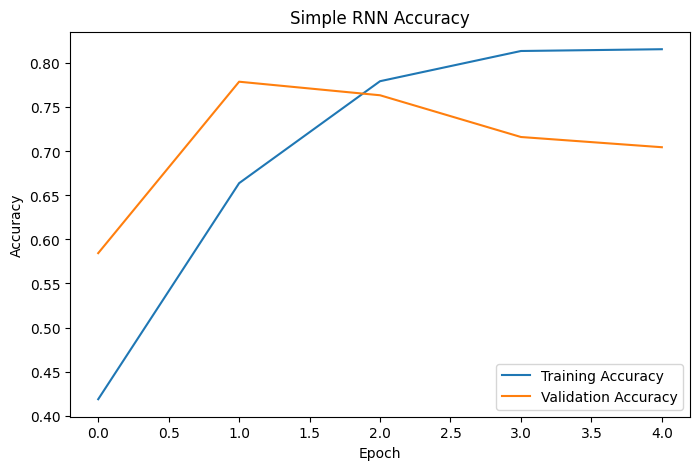

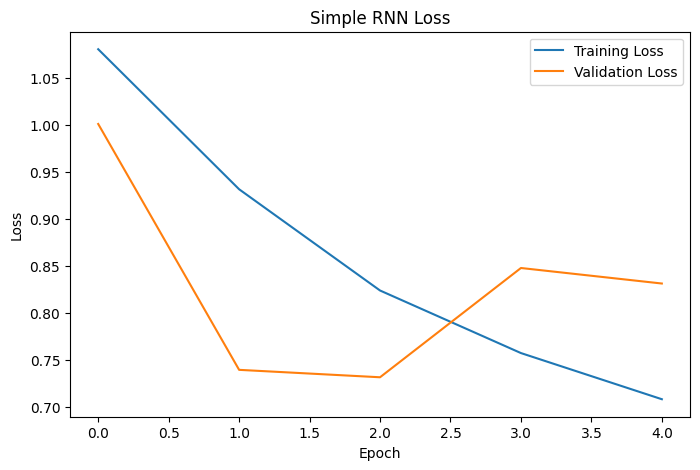

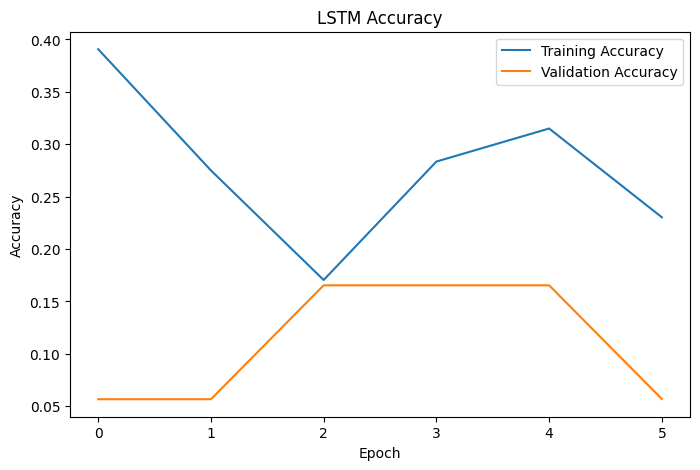

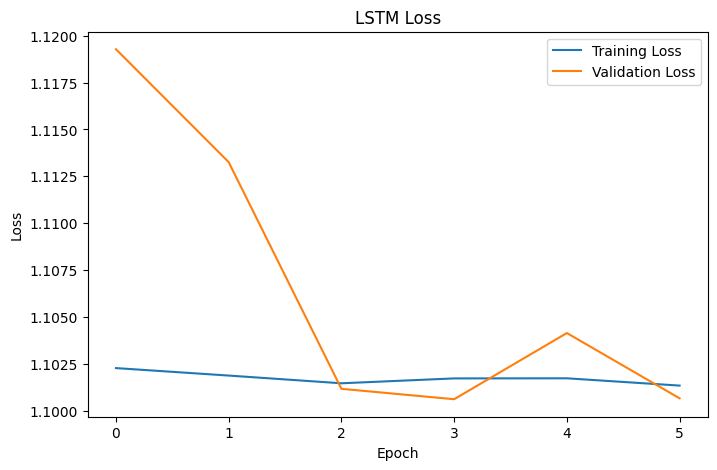

In [49]:
plot_history(
    history_rnn,
    "Simple RNN"
)

plot_history(
    history_lstm,
    "LSTM"
)

In [50]:
def evaluate_model(
    model,
    X_data,
    y_true,
    model_name
):

    probabilities = (
        model.predict(
            X_data,
            verbose=0
        )
    )


    y_pred = np.argmax(
        probabilities,
        axis=1
    )


    metrics = {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "F1-Score":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            )
    }


    print(
        "======================"
    )

    print(
        model_name
    )

    print(
        "======================"
    )


    print(
        classification_report(

            y_true,

            y_pred,

            target_names=[
                "Hate Speech",
                "Offensive Language",
                "Neither"
            ],

            zero_division=0
        )
    )


    cm = confusion_matrix(
        y_true,
        y_pred
    )


    display_cm = (
        ConfusionMatrixDisplay(

            confusion_matrix=cm,

            display_labels=[
                "Hate Speech",
                "Offensive",
                "Neither"
            ]
        )
    )


    display_cm.plot(
        values_format="d"
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.show()


    return metrics, y_pred

Simple RNN
                    precision    recall  f1-score   support

       Hate Speech       0.09      0.15      0.11       286
Offensive Language       0.95      0.78      0.86      3838
           Neither       0.51      0.78      0.62       833

          accuracy                           0.75      4957
         macro avg       0.51      0.57      0.53      4957
      weighted avg       0.82      0.75      0.77      4957



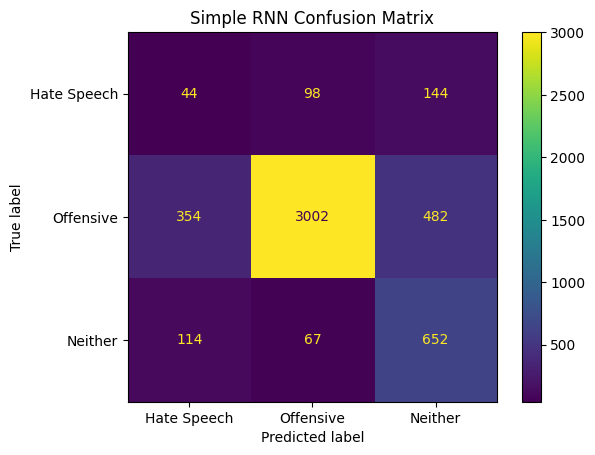

In [51]:
rnn_metrics, rnn_predictions = (
    evaluate_model(

        rnn_model,

        X_test_pad,

        y_test,

        "Simple RNN"
    )
)

LSTM
                    precision    recall  f1-score   support

       Hate Speech       0.00      0.00      0.00       286
Offensive Language       0.00      0.00      0.00      3838
           Neither       0.17      1.00      0.29       833

          accuracy                           0.17      4957
         macro avg       0.06      0.33      0.10      4957
      weighted avg       0.03      0.17      0.05      4957



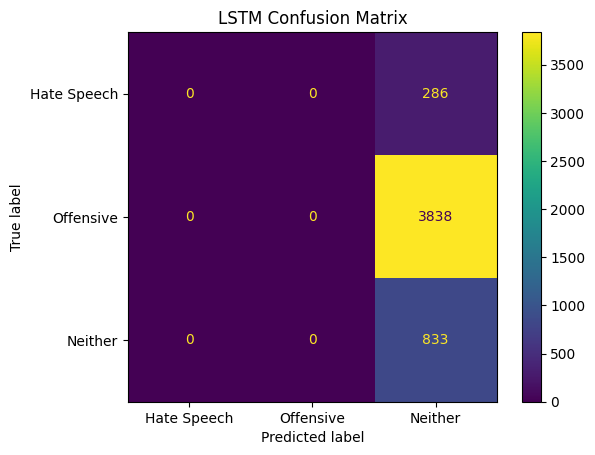

In [52]:
lstm_metrics, lstm_predictions = (
    evaluate_model(

        lstm_model,

        X_test_pad,

        y_test,

        "LSTM"
    )
)

In [53]:
results = pd.DataFrame(
    [
        rnn_metrics,
        lstm_metrics
    ]
)


results

,Model,Accuracy,Precision,Recall,F1-Score
0,Simple RNN,0.746016,0.824610,0.746016,0.773785
1,LSTM,0.168045,0.028239,0.168045,0.048353


In [54]:
best_row = results.loc[
    results[
        "F1-Score"
    ].idxmax()
]


BEST_MODEL_NAME = (
    best_row[
        "Model"
    ]
)


if BEST_MODEL_NAME == "LSTM":

    best_model = (
        lstm_model
    )

else:

    best_model = (
        rnn_model
    )


print(
    "Best model:",
    BEST_MODEL_NAME
)

print(
    "Best F1 Score:",
    best_row[
        "F1-Score"
    ]
)

Best model: Simple RNN
Best F1 Score: 0.773785479313294


In [55]:
MODEL_PATH = (
    "best_hate_speech_model.keras"
)

TOKENIZER_PATH = (
    "tokenizer.pkl"
)

CONFIG_PATH = (
    "model_config.json"
)


best_model.save(
    MODEL_PATH
)


print(
    "Model saved!"
)

Model saved!


In [56]:
with open(
    TOKENIZER_PATH,
    "wb"
) as file:

    pickle.dump(
        tokenizer,
        file
    )


print(
    "Tokenizer saved!"
)

Tokenizer saved!


In [57]:
config = {

    "max_len":
        MAX_LEN,

    "max_words":
        MAX_WORDS,

    "best_model":
        BEST_MODEL_NAME,

    "class_names": {

        "0":
            "Hate Speech",

        "1":
            "Offensive Language",

        "2":
            "Neither"
    }
}


with open(
    CONFIG_PATH,
    "w"
) as file:

    json.dump(
        config,
        file,
        indent=4
    )


print(
    "Configuration saved!"
)

Configuration saved!


In [58]:
def predict_text(text):

    cleaned = clean_text(
        text
    )


    sequence = (
        tokenizer
        .texts_to_sequences(
            [cleaned]
        )
    )


    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )


    probabilities = (
        best_model.predict(
            padded,
            verbose=0
        )[0]
    )


    predicted_class = int(
        np.argmax(
            probabilities
        )
    )


    predicted_label = (
        CLASS_NAMES[
            predicted_class
        ]
    )


    confidence = float(
        probabilities[
            predicted_class
        ]
    )


    print(
        "Original:",
        text
    )

    print(
        "Cleaned:",
        cleaned
    )

    print(
        "Prediction:",
        predicted_label
    )

    print(
        "Confidence:",
        f"{confidence:.2%}"
    )

In [59]:
predict_text(
    "I really enjoyed this movie today."
)

Original: I really enjoyed this movie today.
Cleaned: realli enjoy movi today
Prediction: Neither
Confidence: 44.95%


In [60]:
import os

size_mb = os.path.getsize(
    "best_hate_speech_model.keras"
) / (1024 * 1024)

print(
    f"Model size: {size_mb:.2f} MB"
)

Model size: 7.40 MB


In [61]:
from google.colab import files

files.download(
    "best_hate_speech_model.keras"
)

files.download(
    "tokenizer.pkl"
)

files.download(
    "model_config.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>